In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys
import time

In [25]:
fedavg_bert_aw = [62.95, 86.33, 80.06, 85.08, 89.08, 89.17, 96.88, 98.81, 100.00, 100.00]
krum_bert_aw = [62.95, 86.33, 80.06, 85.08, 69.50, 79.17, 81.92, 72.33, 79.08, 77.52]
multi_krum_bert_aw = [62.95, 39.57, 38.65, 34.84, 34.38, 38.65, 34.61, 37.38, 30.57, 30.27]
trimmed_mean_bert_aw = [62.95, 38.30, 32.11, 46.92, 40.38, 41.19, 49.57, 44.84, 42.00, 46.62]
bulyan_bert_aw = [62.95, 18.15, 13.38, 15.65, 17.04, 18.14, 14.96, 17.27, 17.68, 12.16]
ours_bert_aw = [62.95, 15.47, 9.64, 9.69, 11.76, 7.88, 7.50, 6.50, 6.64, 6.28]

fedavg_bert_as = [81.10, 99.85, 99.40, 69.94, 58.42, 74.38, 99.55, 84.40, 98.07, 99.32]
krum_bert_as = [81.10, 89.05, 100.00, 70.62, 99.11, 81.99, 66.14, 74.40, 69.00, 65.14]
multi_krum_bert_as = [81.10, 62.20, 66.04, 57.74, 87.20, 47.83, 43.63, 41.67, 40.03, 39.92]
trimmed_mean_bert_as = [81.10, 84.85, 58.63, 45.83, 57.29, 80.06, 64.94, 54.49, 48.36, 45.22]
bulyan_bert_as = [81.10, 100.00, 53.87, 41.52, 27.83, 55.98, 37.62, 23.30, 22.00, 20.72]
ours_bert_as = [81.10, 25.36, 21.30, 23.27, 24.35, 15.38, 16.49, 14.96, 13.47, 12.16]

fedavg_bert_lw = [62.95, 64.97, 72.47, 88.21, 82.11, 90.89, 87.59, 88.30, 86.76, 90.77]
krum_bert_lw = [62.95, 54.97, 62.47, 68.21, 72.11, 70.89, 67.59, 68.30, 66.76, 65.14]
multi_krum_bert_lw = [62.95, 52.58, 42.58, 58.21, 52.11, 50.89, 45.59, 43.30, 42.00, 36.40]
trimmed_mean_bert_lw = [62.95, 34.97, 22.47, 48.21, 42.11, 50.89, 57.59, 68.30, 56.76, 66.62]
bulyan_bert_lw = [62.95, 34.97, 32.47, 48.21, 32.11, 40.89, 47.59, 38.30, 29.76, 28.24]
ours_bert_lw = [62.95, 8.23, 10.03, 11.11, 9.57, 9.69, 11.07, 9.46, 10.42, 7.43]

# Calculate the average of the three attack types (addWord, addSent, lwp) for each defense method
fedavg_bert_avg = [(fedavg_bert_aw[i] + fedavg_bert_as[i] + fedavg_bert_lw[i])/3 for i in range(len(fedavg_bert_aw))]
krum_bert_avg = [(krum_bert_aw[i] + krum_bert_as[i] + krum_bert_lw[i])/3 for i in range(len(krum_bert_aw))]
multi_krum_bert_avg = [(multi_krum_bert_aw[i] + multi_krum_bert_as[i] + multi_krum_bert_lw[i])/3 for i in range(len(multi_krum_bert_aw))]
trimmed_mean_bert_avg = [(trimmed_mean_bert_aw[i] + trimmed_mean_bert_as[i] + trimmed_mean_bert_lw[i])/3 for i in range(len(trimmed_mean_bert_aw))]
bulyan_bert_avg = [(bulyan_bert_aw[i] + bulyan_bert_as[i] + bulyan_bert_lw[i])/3 for i in range(len(bulyan_bert_aw))]
ours_bert_avg = [(ours_bert_aw[i] + ours_bert_as[i] + ours_bert_lw[i])/3 for i in range(len(ours_bert_aw))]

In [26]:
ours_bert_avg

[69.0,
 16.353333333333335,
 13.656666666666666,
 14.69,
 15.226666666666667,
 10.983333333333334,
 11.686666666666667,
 10.306666666666667,
 10.176666666666668,
 8.623333333333333]

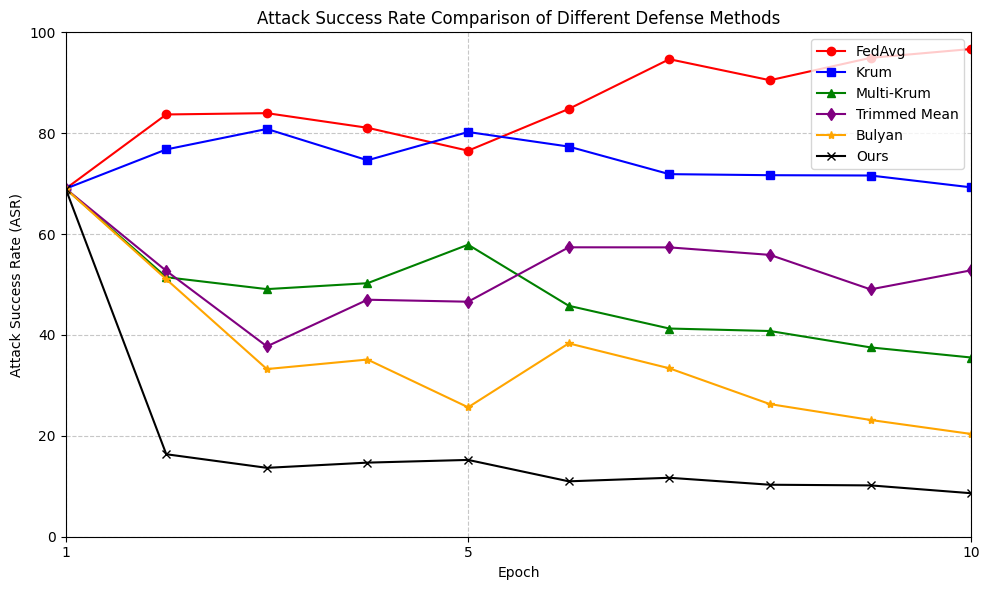

In [29]:
# suppose fedavg, krum, … each have length N
epochs = range(1, len(fedavg_bert_aw) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, fedavg_bert_avg,      marker='o', label='FedAvg',      color='red')
plt.plot(epochs, krum_bert_avg,        marker='s', label='Krum',         color='blue')
plt.plot(epochs, multi_krum_bert_avg,  marker='^', label='Multi-Krum',   color='green')
plt.plot(epochs, trimmed_mean_bert_avg,marker='d', label='Trimmed Mean', color='purple')
plt.plot(epochs, bulyan_bert_avg,      marker='*', label='Bulyan',       color='orange')
plt.plot(epochs, ours_bert_avg,        marker='x', label='Ours',         color='black')

plt.xlabel('Epoch')
plt.ylabel('Attack Success Rate (ASR)')
plt.title('Attack Success Rate Comparison of Different Defense Methods')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')

# make sure the x-axis ticks show 1, 2, 3, …
plt.xticks([1, 5, 10])

plt.ylim(0, 100)
plt.xlim(1, 10)
plt.tight_layout()
plt.show()

In [ ]:
fedavg_dis_aw = []
krum_dis_aw = []
multi_krum_dis_aw = []
trimmed_mean_dis_aw = []
bulyan_dis_aw = []
ours_dis_aw = []

fedavg_dis_as = []
krum_dis_as = []
multi_krum_dis_as = []
trimmed_mean_dis_as = []
bulyan_dis_as = []
ours_dis_as = []

fedavg_dis_lw = []
krum_dis_lw = []
multi_krum_dis_lw = []
trimmed_mean_dis_lw = []
bulyan_dis_lw = []
ours_dis_lw = []

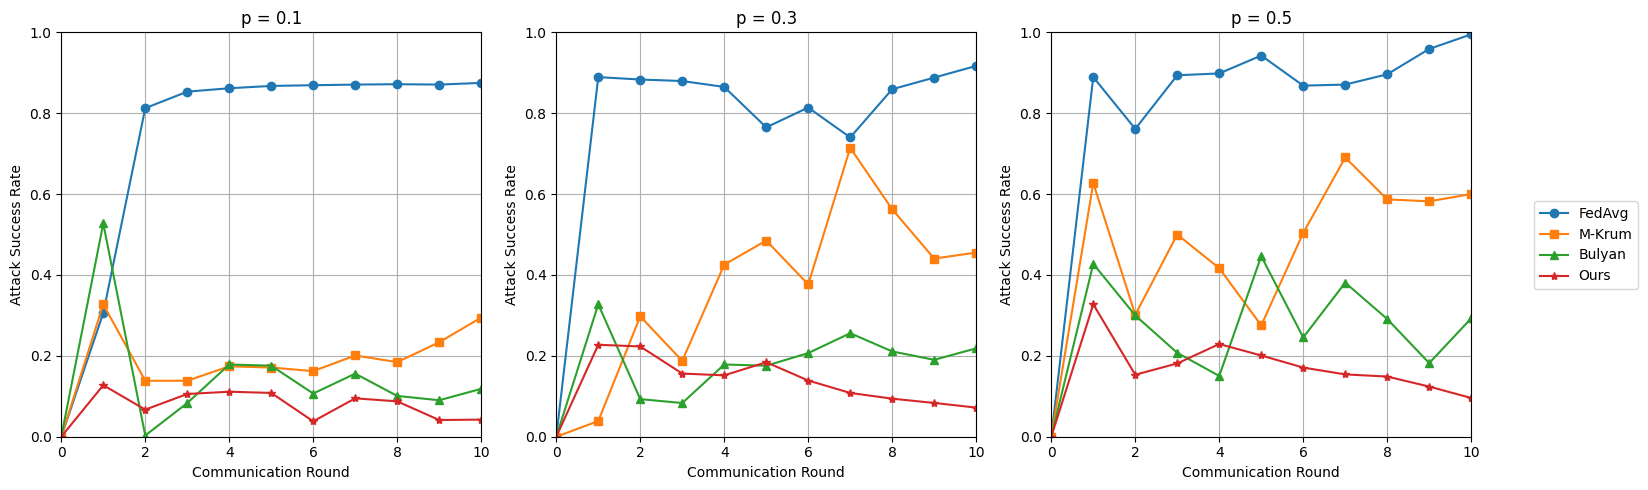

In [61]:
# plot for different poison ratios
poison_ratios = [0.1, 0.3, 0.5]

fedavg_01 = [0, 0.3058, 0.8125, 0.8533, 0.8617, 0.8675, 0.8692, 0.8708, 0.8717, 0.8708, 0.8750]
mkrum_01 = [0, 0.3274, 0.1384, 0.1384, 0.1741, 0.1711, 0.1622, 0.2009, 0.1845, 0.2336, 0.2946]
bulyan_01 = [0, 0.5274, 0.0030, 0.0833, 0.1786, 0.1756, 0.1068, 0.1560, 0.1009, 0.0902, 0.1185]
ours_01 = [0, 0.1274, 0.0670, 0.1057, 0.1113, 0.1083, 0.0381, 0.0949, 0.0875, 0.0413, 0.0423]

fedavg_03 = [0, 0.8893, 0.8833, 0.8796, 0.865, 0.765, 0.814, 0.7401, 0.8593, 0.8881, 0.9170]
mkrum_03 = [0, 0.0387, 0.2976, 0.1875, 0.4256, 0.4851, 0.3765, 0.7143, 0.5625, 0.4405, 0.4554]
bulyan_03 = [0, 0.3274, 0.0930, 0.0833, 0.1786, 0.1756, 0.2068, 0.2560, 0.2109, 0.1902, 0.2185]
ours_03 = [0, 0.2274, 0.2232, 0.1562, 0.1518, 0.1842, 0.1390, 0.1083, 0.0941, 0.0835, 0.0720]

fedavg_05 = [0, 0.8893, 0.7612, 0.8938, 0.8984, 0.9426, 0.8682, 0.8708, 0.8962, 0.9589, 0.9950]
mkrum_05 = [0, 0.6274, 0.3015, 0.5, 0.4167, 0.2753, 0.5039, 0.6905, 0.5869, 0.5821, 0.6]
bulyan_05 = [0, 0.4274, 0.3, 0.2074, 0.1503, 0.4464, 0.2455, 0.3810, 0.2911, 0.1821, 0.2926]
ours_05 = [0, 0.3274, 0.1533, 0.1812, 0.2292, 0.2009, 0.1710, 0.1541, 0.1488, 0.1240, 0.0958]

plt.figure(figsize=(15, 5))

# Plot for poison ratio 0.1
plt.subplot(1, 3, 1)
plt.plot(range(0, 11), fedavg_01, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_01, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_01, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_01, marker='*', label='Ours')
plt.title('p = 0.1')
plt.xlabel('Communication Round')
plt.ylabel('Attack Success Rate')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Plot for poison ratio 0.3
plt.subplot(1, 3, 2)
plt.plot(range(0, 11), fedavg_03, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_03, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_03, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_03, marker='*', label='Ours')
plt.title('p = 0.3')
plt.xlabel('Communication Round')
plt.ylabel('Attack Success Rate')
plt.xlim(0, 10)
plt.ylim(0, 1.0)
plt.grid(True)

# Plot for poison ratio 0.5
plt.subplot(1, 3, 3)
plt.plot(range(0, 11), fedavg_05, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_05, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_05, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_05, marker='*', label='Ours')
plt.title('p = 0.5')
plt.xlabel('Communication Round')
plt.ylabel('Attack Success Rate')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Create a single legend outside the plots
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()
plt.show()


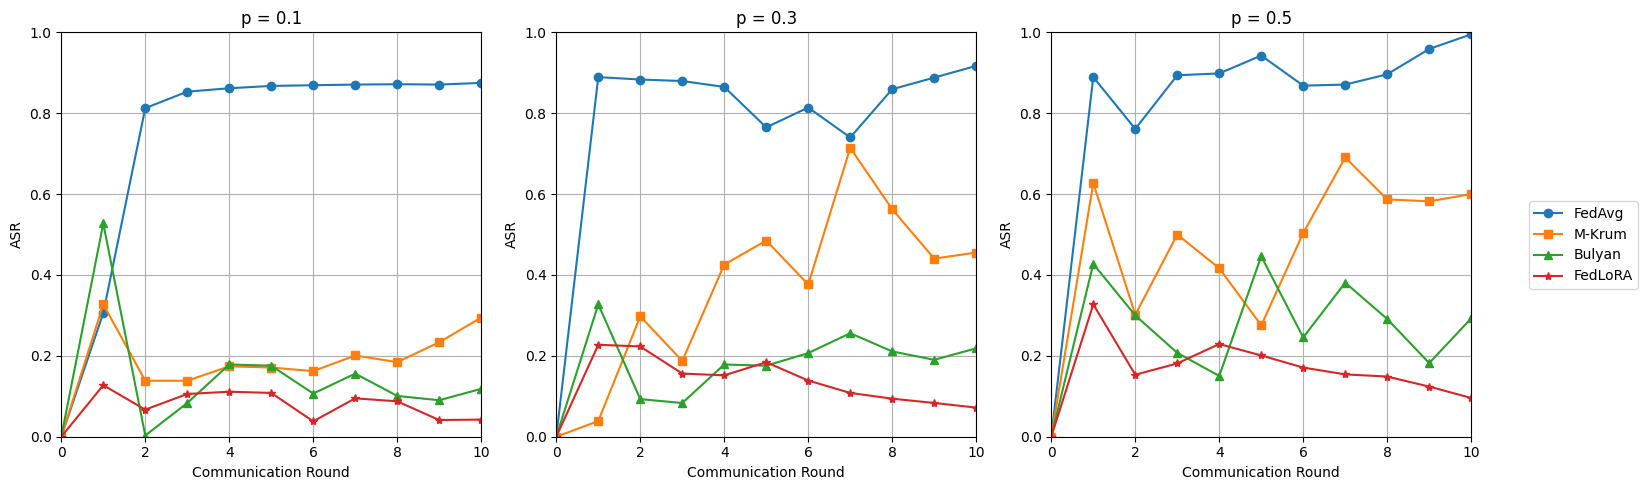

In [62]:
# Save the figure to PDF
plt.figure(figsize=(15, 5))

# Plot for poison ratio 0.1
plt.subplot(1, 3, 1)
plt.plot(range(0, 11), fedavg_01, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_01, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_01, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_01, marker='*', label='FedLoRA')
plt.title('p = 0.1')
plt.xlabel('Communication Round')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Plot for poison ratio 0.3
plt.subplot(1, 3, 2)
plt.plot(range(0, 11), fedavg_03, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_03, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_03, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_03, marker='*', label='FedLoRA')
plt.title('p = 0.3')
plt.xlabel('Communication Round')
plt.ylabel('ASR')
plt.xlim(0, 10)
plt.ylim(0, 1.0)
plt.grid(True)

# Plot for poison ratio 0.5
plt.subplot(1, 3, 3)
plt.plot(range(0, 11), fedavg_05, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_05, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_05, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_05, marker='*', label='FedLoRA')
plt.title('p = 0.5')
plt.xlabel('Communication Round')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Create a single legend outside the plots
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()

# Save the figure to PDF
plt.savefig('fig/ratio.pdf', bbox_inches='tight', dpi=300)
plt.show()


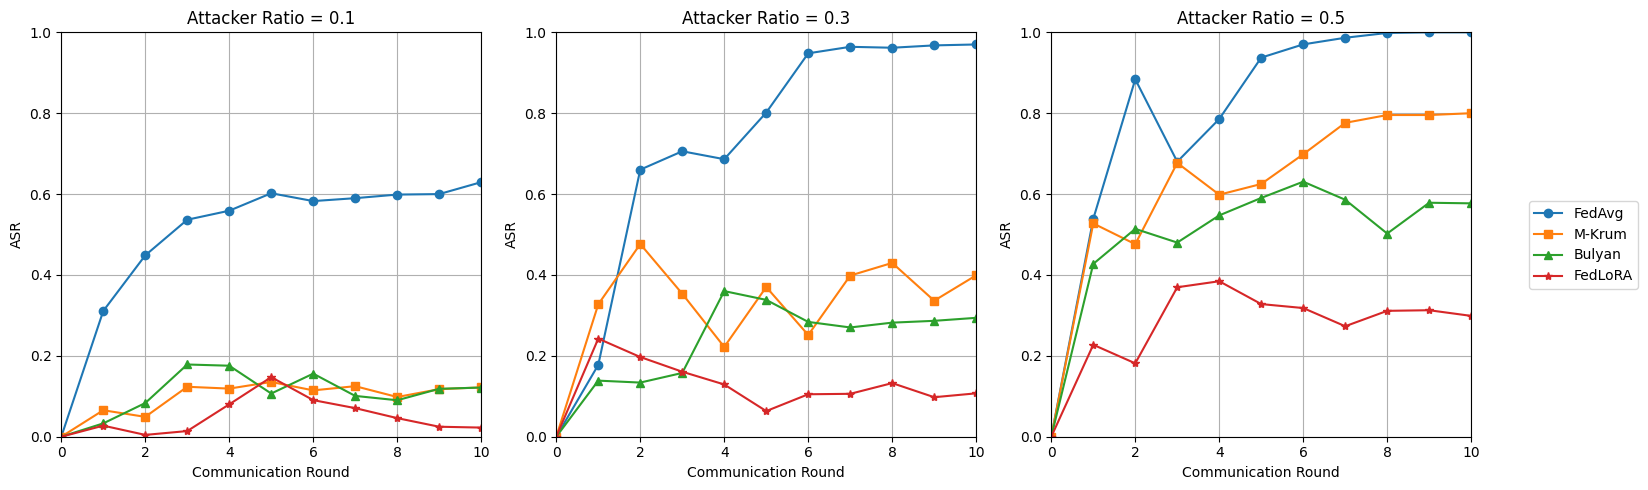

In [60]:
# plot attackers
attackers = [0.1, 0.3, 0.5]

# Add 0 to the start of each data array
fed_01 = [0] + [0.3110, 0.4485, 0.5366, 0.5589, 0.6021, 0.5827, 0.5899, 0.5988, 0.6, 0.6295]
mkrum_01 = [0] + [0.0655, 0.0491, 0.1235, 0.1190, 0.1354, 0.1146, 0.1250, 0.0982, 0.1176, 0.1220]
bulyan_01 = [0] + [0.0330, 0.0833, 0.1786, 0.1756, 0.1068, 0.1560, 0.1009, 0.0902, 0.1185, 0.1216]
ours_01 = [0] + [0.0274, 0.0045, 0.0140, 0.0801, 0.1473, 0.0905, 0.0707, 0.0460, 0.0247, 0.0226]

fed_03 = [0] + [0.1776, 0.6604, 0.7059, 0.6863, 0.8016, 0.9481, 0.9642, 0.9619, 0.9677, 0.9700]
mkrum_03 = [0] + [0.3274, 0.4765, 0.3536, 0.2220, 0.3702, 0.2515, 0.3985, 0.4298, 0.3363, 0.3992]
bulyan_03 = [0] + [0.1387, 0.1339, 0.1577, 0.3601, 0.3384, 0.2839, 0.2702, 0.2821, 0.2866, 0.2940]
ours_03 = [0] + [0.2426, 0.1971, 0.1607, 0.1292, 0.0634, 0.1050, 0.1061, 0.1326, 0.0977, 0.1073]

fed_05 = [0] + [0.5387, 0.8839, 0.6801, 0.7857, 0.9375, 0.9702, 0.9866, 0.9985, 1.0000, 1.0000]
mkrum_05 = [0] + [0.5274, 0.4762, 0.6771, 0.5985, 0.6250, 0.6985, 0.7762, 0.7955, 0.7955, 0.8000]
bulyan_05 = [0] + [0.4274, 0.5140, 0.4801, 0.5473, 0.5905, 0.6307, 0.5860, 0.5024, 0.5786, 0.5771]
ours_05 = [0] + [0.2274, 0.1815, 0.3696, 0.3845, 0.3280, 0.3182, 0.2732, 0.3113, 0.3128, 0.2988]

# Create a figure with 3 subplots for different attacker ratios
plt.figure(figsize=(15, 5))

# Plot for attacker ratio 0.1
plt.subplot(1, 3, 1)
plt.plot(range(0, 11), fed_01, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_01, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_01, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_01, marker='*', label='FedLoRA')
plt.title('Attacker Ratio = 0.1')
plt.xlabel('Communication Round')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Plot for attacker ratio 0.3
plt.subplot(1, 3, 2)
plt.plot(range(0, 11), fed_03, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_03, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_03, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_03, marker='*', label='FedLoRA')
plt.title('Attacker Ratio = 0.3')
plt.xlabel('Communication Round')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Plot for attacker ratio 0.5
plt.subplot(1, 3, 3)
plt.plot(range(0, 11), fed_05, marker='o', label='FedAvg')
plt.plot(range(0, 11), mkrum_05, marker='s', label='M-Krum')
plt.plot(range(0, 11), bulyan_05, marker='^', label='Bulyan')
plt.plot(range(0, 11), ours_05, marker='*', label='FedLoRA')
plt.title('Attacker Ratio = 0.5')
plt.xlabel('Communication Round')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.xlim(0, 10)
plt.grid(True)

# Create a single legend outside the plots
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()

# Save the figure to PDF
plt.savefig('fig/attackers.pdf', bbox_inches='tight', dpi=300)
plt.show()

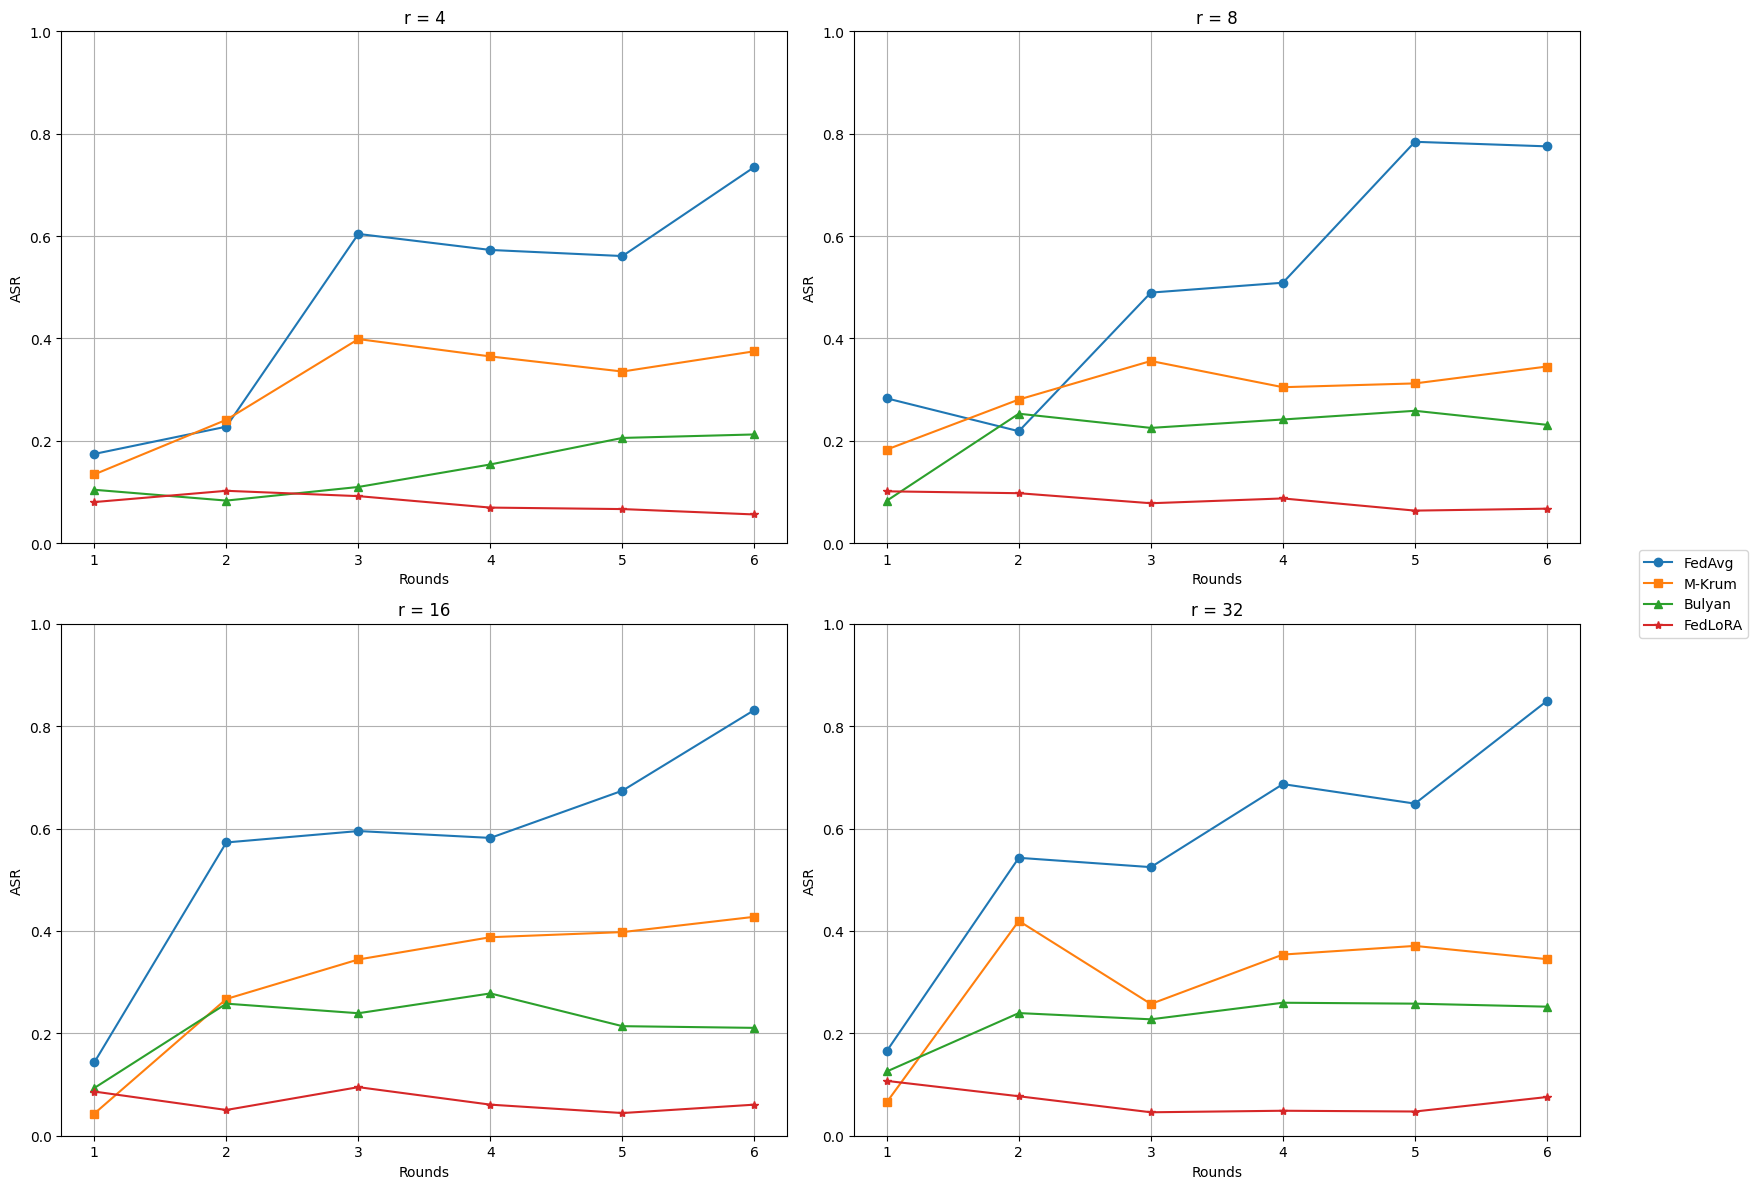

In [6]:
# plot for different lora ranks
lora_ranks = [4, 8, 16, 32]

# Add 0 to the start of each data array
fed_4 = [0.1744, 0.2277, 0.6042, 0.5729, 0.5610, 0.7351]
fed_8 = [0.2830, 0.2188, 0.4896, 0.5089, 0.7842, 0.7753]
fed_16 = [0.1432, 0.5729, 0.5952, 0.5818, 0.6741, 0.8318]
fed_32 = [0.1655, 0.5429, 0.5247, 0.6869, 0.6488, 0.8494]


m_krum_4 = [0.1344, 0.2411, 0.3988, 0.3649, 0.3354, 0.3750]
m_krum_8 = [0.1830, 0.2807, 0.3560, 0.3048, 0.3122, 0.3452]
m_krum_16 = [0.0432, 0.2671, 0.3443, 0.3878, 0.3978, 0.4277]
m_krum_32 = [0.0655, 0.4196, 0.2574, 0.3539, 0.3708, 0.3449]

bulyan_4 = [0.1044, 0.0833, 0.1099, 0.1539, 0.2057, 0.2125]
bulyan_8 = [0.0830, 0.2530, 0.2253, 0.2417, 0.2587, 0.2313]
bulyan_16 = [0.0932, 0.2580, 0.2393, 0.2780, 0.2140, 0.2107]
bulyan_32 = [0.1255, 0.2396, 0.2274, 0.2598, 0.2580, 0.2521]

ours_4 = [0.0804, 0.1024, 0.0920, 0.0696, 0.0667, 0.0562]
ours_8 = [0.1014, 0.0977, 0.0781, 0.0875, 0.0637, 0.0675]
ours_16 = [0.0863, 0.0503, 0.0949, 0.0607, 0.0443, 0.0607]
ours_32 = [0.1071, 0.0771, 0.0458, 0.0488, 0.0473, 0.0756]

# Create a figure with 4 subplots (one for each LoRA rank)
plt.figure(figsize=(16, 12))

# Define x-axis values (communication rounds)
rounds = range(1, 7)  # 6 rounds

# Plot for LoRA rank = 4
plt.subplot(2, 2, 1)
plt.plot(rounds, fed_4, marker='o', label='FedAvg')
plt.plot(rounds, m_krum_4, marker='s', label='M-Krum')
plt.plot(rounds, bulyan_4, marker='^', label='Bulyan')
plt.plot(rounds, ours_4, marker='*', label='FedLoRA')
plt.title('r = 4')
plt.xlabel('Rounds')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.grid(True)

# Plot for LoRA rank = 8
plt.subplot(2, 2, 2)
plt.plot(rounds, fed_8, marker='o', label='FedAvg')
plt.plot(rounds, m_krum_8, marker='s', label='M-Krum')
plt.plot(rounds, bulyan_8, marker='^', label='Bulyan')
plt.plot(rounds, ours_8, marker='*', label='FedLoRA')
plt.title('r = 8')
plt.xlabel('Rounds')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.grid(True)

# Plot for LoRA rank = 16
plt.subplot(2, 2, 3)
plt.plot(rounds, fed_16, marker='o', label='FedAvg')
plt.plot(rounds, m_krum_16, marker='s', label='M-Krum')
plt.plot(rounds, bulyan_16, marker='^', label='Bulyan')
plt.plot(rounds, ours_16, marker='*', label='FedLoRA')
plt.title('r = 16')
plt.xlabel('Rounds')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.grid(True)

# Plot for LoRA rank = 32
plt.subplot(2, 2, 4)
plt.plot(rounds, fed_32, marker='o', label='FedAvg')
plt.plot(rounds, m_krum_32, marker='s', label='M-Krum')
plt.plot(rounds, bulyan_32, marker='^', label='Bulyan')
plt.plot(rounds, ours_32, marker='*', label='FedLoRA')
plt.title('r = 32')
plt.xlabel('Rounds')
plt.ylabel('ASR')
plt.ylim(0, 1.0)
plt.grid(True)

# Create a single legend outside the plots
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()

# Save the figure to PDF
plt.savefig('fig/ranks.pdf', bbox_inches='tight', dpi=300)
plt.show()
